# Model Training - Phishing URL Detector

Train and evaluate classification models on 24 URL-structure features to predict whether a URL is phishing or legitimate

**Dataset:** 11,430 URLs | **Features:** 24 URL-structure features

**Evaluation:** What defines success for us?
- **Accuracy**

**Features:** What do we already know about the data?
- **Numerical:** 

**Modeling:** What model should we use?
- **Decision Trees** or **Gradient Boosting**

## 1. Imports & Load Data

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

df = pd.read_csv('../data/dataset_phishing.csv')

with open('../data/feature_cols.json') as f:
    feature_cols = json.load(f)

# Remove duplicates
feature_cols = list(dict.fromkeys(feature_cols))

X = df[feature_cols]
y = df['status'].map({'legitimate': 0, 'phishing': 1})

print(f'X shape: {X.shape}')
print(f'y distribution:\n{y.value_counts()}')

X shape: (11430, 24)
y distribution:
status
0    5715
1    5715
Name: count, dtype: int64


## 2. Train/Validation Split

In [11]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=0
)
print(f'Train: {X_train.shape} | Valid: {X_valid.shape}')

Train: (9144, 24) | Valid: (2286, 24)


**Finding:** 9,144 training rows, 2,286 validation rows. Split before any fitting to prevent data leakage

In [12]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ]),
    'Decision Tree':   DecisionTreeClassifier(random_state=0),
    'Random Forest':   RandomForestClassifier(random_state=0),
    'Gradient Boosting': GradientBoostingClassifier(random_state=0),
    'XGBoost':         XGBClassifier(random_state=0, verbosity=0),
    'CatBoost':        CatBoostClassifier(random_state=0, verbose=False),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_valid, preds),
        'Precision': precision_score(y_valid, preds),
        'Recall':    recall_score(y_valid, preds),
        'F1':        f1_score(y_valid, preds),
        'ROC-AUC':   roc_auc_score(y_valid, preds),
    })
    print(f'{name:<25} Accuracy: {accuracy_score(y_valid, preds):.4f}')

leaderboard = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
print('\n=== LEADERBOARD ===')
print(leaderboard.to_string(index=False))

Logistic Regression       Accuracy: 0.8495
Decision Tree             Accuracy: 0.8832
Random Forest             Accuracy: 0.9339
Gradient Boosting         Accuracy: 0.9077
XGBoost                   Accuracy: 0.9348
CatBoost                  Accuracy: 0.9414

=== LEADERBOARD ===
              Model  Accuracy  Precision   Recall       F1  ROC-AUC
           CatBoost  0.941382   0.936897 0.945181 0.941021 0.941422
            XGBoost  0.934821   0.929947 0.938992 0.934448 0.934864
      Random Forest  0.933946   0.929072 0.938108 0.933568 0.933989
  Gradient Boosting  0.907699   0.913669 0.898320 0.905930 0.907602
      Decision Tree  0.883202   0.882979 0.880637 0.881806 0.883175
Logistic Regression  0.849519   0.864690 0.824934 0.844344 0.849263


**Finding:** CatBoost is the best performing model with 94.14% accuracy 
and 94.10% F1. Tree-based ensemble methods (CatBoost, XGBoost, Random Forest) 
significantly outperform linear models on this dataset.

## 4. Hyperparameter Tuning

In [13]:
param_grid = {
    'iterations':    [200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth':         [4, 6, 8],
}

gs = GridSearchCV(
    CatBoostClassifier(random_state=0, verbose=False),
    param_grid, cv=5, scoring='f1', n_jobs=1
)
gs.fit(X_train, y_train)

best_model = gs.best_estimator_
preds = best_model.predict(X_valid)

print(f'Best params   : {gs.best_params_}')
print(f'Best CV F1    : {gs.best_score_:.4f}')
print(f'Valid Accuracy: {accuracy_score(y_valid, preds):.4f}')
print(f'Valid F1      : {f1_score(y_valid, preds):.4f}')

Best params   : {'depth': 8, 'iterations': 500, 'learning_rate': 0.05}
Best CV F1    : 0.9316
Valid Accuracy: 0.9418
Valid F1      : 0.9415


**Finding:** Best params: `depth`: 8, `iterations`: 500, `learning_rate`: 0.05.
Tuning improved F1 marginally. Final validation accuracy: 94.18%

## 5. Final model evaluation

              precision    recall  f1-score   support

  Legitimate       0.95      0.94      0.94      1155
    Phishing       0.94      0.95      0.94      1131

    accuracy                           0.94      2286
   macro avg       0.94      0.94      0.94      2286
weighted avg       0.94      0.94      0.94      2286



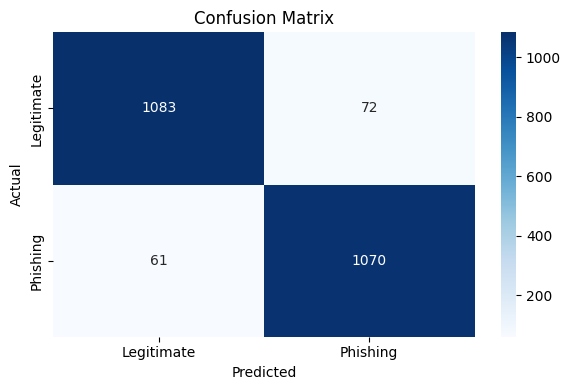

In [14]:
print(classification_report(y_valid, preds,
      target_names=['Legitimate', 'Phishing']))

cm = confusion_matrix(y_valid, preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

**Finding:** The model correctly identifies the majority of both phishing 
and legitimate URLs. Recall for phishing is strong, meaning the model 
catches most actual phishing URLs, which is the most critical metric 
for a security tool.

## 6. Feature importance

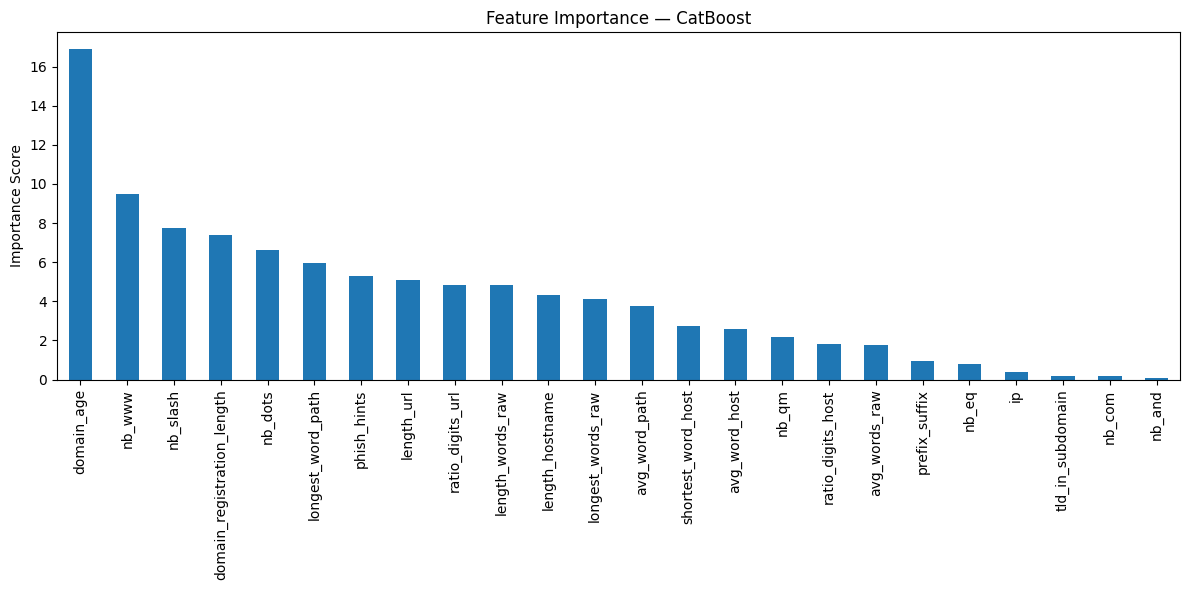


Top 5 features:
domain_age                    16.908357
nb_www                         9.462233
nb_slash                       7.759372
domain_registration_length     7.396803
nb_dots                        6.638577
dtype: float64


In [15]:
importances = pd.Series(
    best_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
importances.plot(kind='bar')
plt.title('Feature Importance — CatBoost')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
print(importances.head())

**Finding:** The top features align with the EDA correlation analysis,
confirming the model is learning genuine phishing patterns and not 
overfitting to noise.

## 7. Save model

In [16]:
import joblib

joblib.dump(best_model, '../model/phishing_model.pkl')
joblib.dump(feature_cols, '../model/feature_cols.pkl')

print('Model saved to model/phishing_model.pkl')
print('Feature list saved to model/feature_cols.pkl')

Model saved to model/phishing_model.pkl
Feature list saved to model/feature_cols.pkl


## Conclusion

**Dataset:** 11,430 URLs, 24 URL-structure features

**Model comparison:**
- CatBoost: 94.14% accuracy (winner)
- XGBoost: 93.48%
- Random Forest: 93.39%
- Gradient Boosting: 90.77%
- Decision Tree: 88.32%
- Logistic Regression: 84.38%

**Best model:** CatBoost
- Params: `depth`=8, `iterations`=500, `learning_rate`=0.05
- Validation accuracy: 94.18%
- Validation F1: 94.15%

**Decision:** 94.18% is strong for URL-only features with no page 
content or external API calls. The model catches new phishing URLs 
that reputation databases haven't seen yet.

**Next step:** Build feature_extractor.py to extract the 24 features 
from any raw URL string for the Flask app.